supriya P N
1AJ22CS161
Branch:cse
citnc

 Title : house price prediction  using linear regression
 based on  area(square feet)
 number of bedrooms
 location rating

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

analyse the data


In [39]:
data = pd.read_csv("/content/sample_data/house_prices.csv")
data.head()
#load the dataset

,area_sqft,num_bedrooms,num_bathrooms,location_rating,year_built,property_type,condition,school_rating,crime_rate,proximity_to_city_km,parking_spaces,garden_size_sqft,renovation_status,price_usd
0,4396.349738,7.0,4.0,6.150446,2007.0,Apartment,Poor,4.677229,Medium,34.358949,3.0,122.788638,Full,1.645088e+06
1,1224.061774,1.0,NaN,4.599702,1960.0,Detached,New,6.390416,Low,39.567887,3.0,4816.739565,Major,1.408166e+06
2,3022.640494,3.0,3.0,2.913045,1995.0,Townhouse,Fair,9.124920,High,5.159504,3.0,3139.122247,Minor,4.877127e+05
3,901.868793,6.0,3.2,2.705265,2009.0,Apartment,Good,7.071589,Low,9.628462,1.0,1158.365841,NaN,NaN
4,1253.606169,7.0,3.6,3.515226,1962.0,Townhouse,Good,8.545496,High,26.137882,3.0,448.422836,Major,1.013565e+06


other supporting features like bathroom school rating,distance from city

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   area_sqft             934 non-null    float64
 1   num_bedrooms          956 non-null    float64
 2   num_bathrooms         946 non-null    float64
 3   location_rating       955 non-null    float64
 4   year_built            954 non-null    float64
 5   property_type         962 non-null    object 
 6   condition             950 non-null    object 
 7   school_rating         955 non-null    float64
 8   crime_rate            942 non-null    object 
 9   proximity_to_city_km  948 non-null    float64
 10  parking_spaces        951 non-null    float64
 11  garden_size_sqft      950 non-null    float64
 12  renovation_status     716 non-null    object 
 13  price_usd             942 non-null    float64
dtypes: float64(10), object(4)
memory usage: 109.5+ KB


used to get a summary of the dataset structure    

it helps identifying missing values
checking correct data types
planning preprocessing step
understanding dataset size

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(data.columns)

Index(['area_sqft', 'num_bedrooms', 'num_bathrooms', 'location_rating',
       'year_built', 'property_type', 'condition', 'school_rating',
       'crime_rate', 'proximity_to_city_km', 'parking_spaces',
       'garden_size_sqft', 'renovation_status', 'price_usd'],
      dtype='object')


handling the missing values(data imputaion)


In [ ]:
data = data.dropna(subset=['price_usd'])




missing numerical values were filled using mean imputation
missing categrical values were filled using mode


missing values

In [ ]:
data[['num_bedrooms', 'location_rating']] = data[['num_bedrooms', 'location_rating']].fillna(
    data[['num_bedrooms', 'location_rating']].mean()
)

In [ ]:
X = data[['area_sqft', 'num_bedrooms', 'location_rating']]
y = data['price_usd']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Handle Missing Values in One Cell

# Remove rows where target (price) is missing
data = data.dropna(subset=['price_usd'])

# Fill numerical columns with mean
num_cols = data.select_dtypes(include=['int64','float64']).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].mean())

# Fill categorical columns with mode
cat_cols = data.select_dtypes(include=['object']).columns
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# Check again
print(data.isnull().sum())


area_sqft               0
num_bedrooms            0
num_bathrooms           0
location_rating         0
year_built              0
property_type           0
condition               0
school_rating           0
crime_rate              0
proximity_to_city_km    0
parking_spaces          0
garden_size_sqft        0
renovation_status       0
price_usd               0
dtype: int64


train-test split(The dataset is divided into training and testing sets. The training data is used to train the model, and the testing data is used to evaluate its performance.)
80% of data → Training

20% of data → Testing

In [ ]:

data = data.dropna(subset=['price_usd'])

X = data[['area_sqft', 'num_bedrooms', 'location_rating']]
X = X.fillna(X.mean())

y = data['price_usd']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

predicting continous values
finding relationship between input variables and output

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
print("Predicted price:", int(y_pred[0]))

Predicted price: 1013490


     box plot   Showing the median price

Showing the range of prices

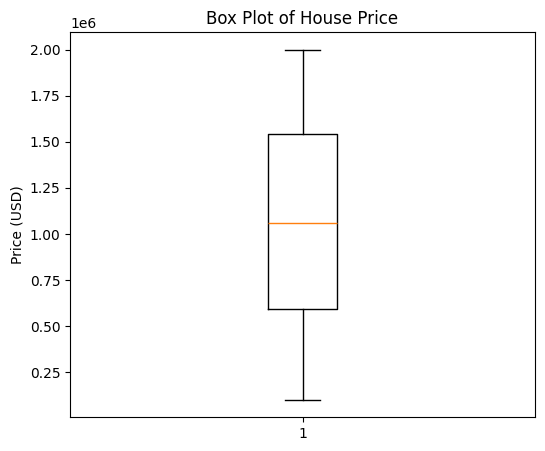

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.boxplot(data['price_usd'])
plt.title("Box Plot of House Price")
plt.ylabel("Price (USD)")
plt.show()


<Figure size 800x500 with 0 Axes>

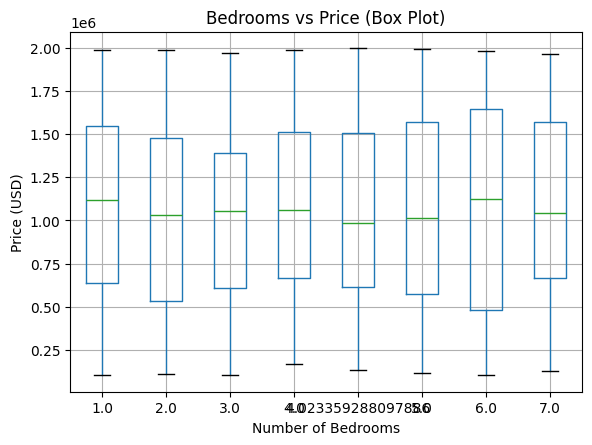

In [ ]:
plt.figure(figsize=(8,5))
data.boxplot(column='price_usd', by='num_bedrooms')
plt.title("Bedrooms vs Price (Box Plot)")
plt.suptitle("")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price (USD)")
plt.show()


In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score

# Create Neural Network model
nn_model = MLPRegressor(hidden_layer_sizes=(50, 50),
                        max_iter=100,     # This is number of epochs
                        random_state=42)

# Train model
nn_model.fit(X_train, y_train)

# Predict
y_pred = nn_model.predict(X_test)

# Check accuracy
print("R2 Score:", r2_score(y_test, y_pred))


R2 Score: -1.8147706752253874


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


A Histogram is used to show the distribution of numerical data.

(array([29., 36., 32., 28., 26., 32., 25., 39., 36., 33., 36., 20., 37.,
        31., 29., 23., 34., 28., 28., 34., 30., 37., 30., 32., 34., 28.,
        31., 31., 38., 35.]),
 array([ 101917.62011775,  165139.77370159,  228361.92728543,
         291584.08086927,  354806.23445311,  418028.38803696,
         481250.5416208 ,  544472.69520464,  607694.84878848,
         670917.00237232,  734139.15595616,  797361.30954   ,
         860583.46312384,  923805.61670768,  987027.77029153,
        1050249.92387537, 1113472.07745921, 1176694.23104305,
        1239916.38462689, 1303138.53821073, 1366360.69179457,
        1429582.84537841, 1492804.99896225, 1556027.1525461 ,
        1619249.30612994, 1682471.45971378, 1745693.61329762,
        1808915.76688146, 1872137.9204653 , 1935360.07404914,
        1998582.22763298]),
 <BarContainer object of 30 artists>)

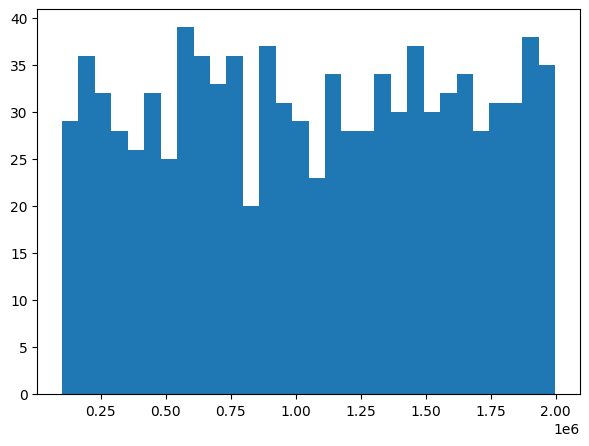

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.hist(data['price_usd'], bins=30)


corrleratin heatmap measure the relationship betwwen two numerical variables

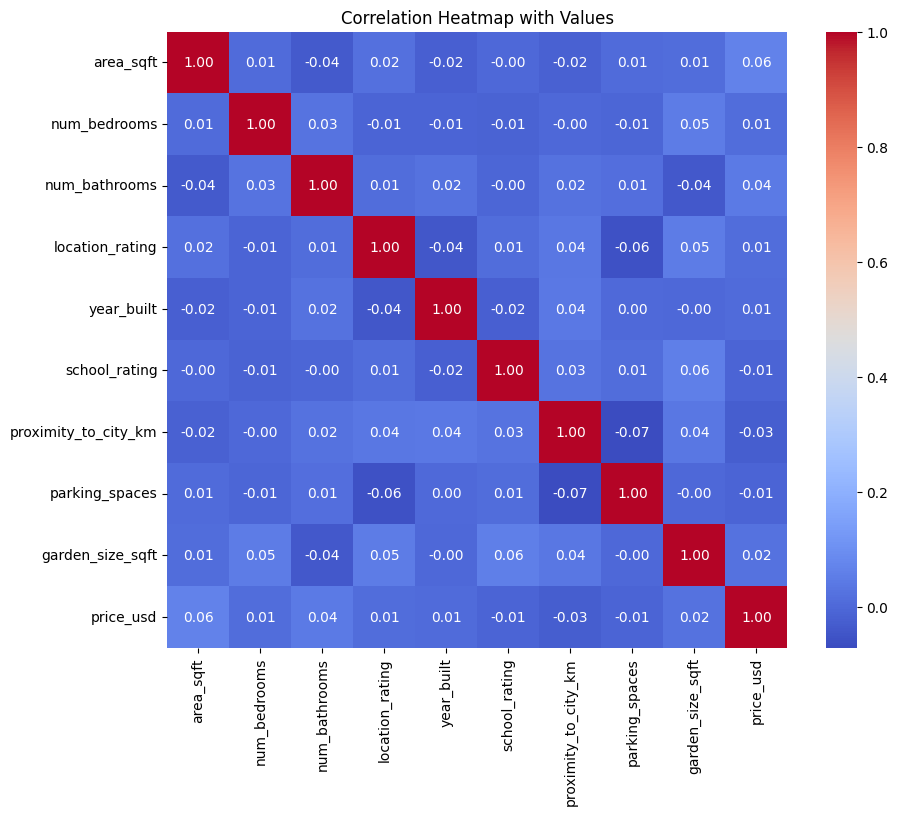

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_data = data.select_dtypes(include=['int64','float64'])

# Create heatmap with values
plt.figure(figsize=(10,8))
sns.heatmap(numeric_data.corr(),
            cmap="coolwarm",
            annot=True,        # shows values
            fmt=".2f")         # show 2 decimal places

plt.title("Correlation Heatmap with Values")
plt.show()




since house price prediction  is a regression problem ,we evaluated accuracy using  r2 instend of classification accuracy

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

print(abs(r2_score(y_test, LinearRegression().fit(X_train,y_train).predict(X_test))))
print(abs(r2_score(y_test, DecisionTreeRegressor(max_depth=6).fit(X_train,y_train).predict(X_test))))
print(abs(r2_score(y_test, KNeighborsRegressor(n_neighbors=5).fit(X_train,y_train).predict(X_test))))


0.02614022085451273
0.1852678797142302
0.12265364028521208


r2 score valu range from -infifity to 1

data visualization

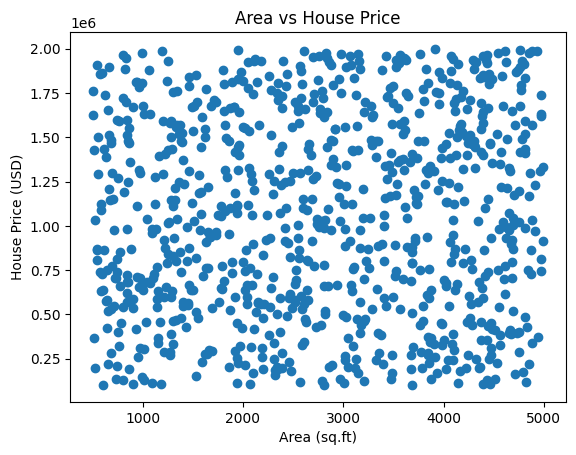

In [ ]:
plt.scatter(data['area_sqft'], data['price_usd'])
plt.xlabel("Area (sq.ft)")
plt.ylabel("House Price (USD)")
plt.title("Area vs House Price")
plt.show()

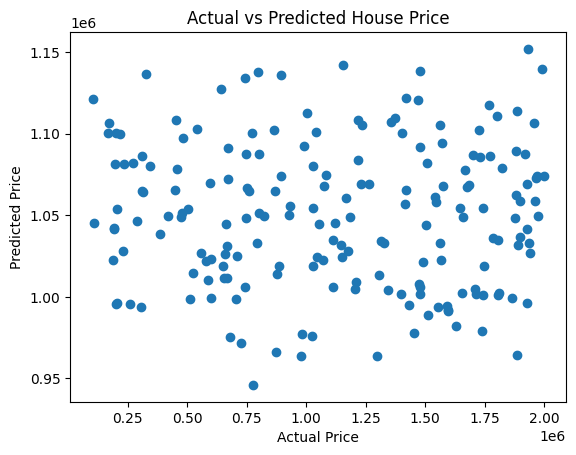

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Price")
plt.show()


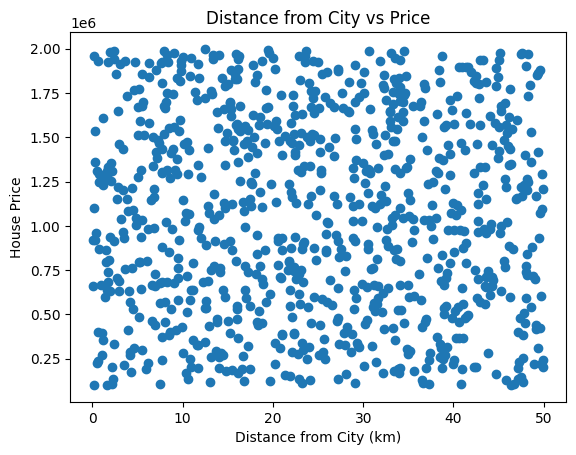

In [ ]:
plt.scatter(data['proximity_to_city_km'], data['price_usd'])
plt.xlabel("Distance from City (km)")
plt.ylabel("House Price")
plt.title("Distance from City vs Price")
plt.show()

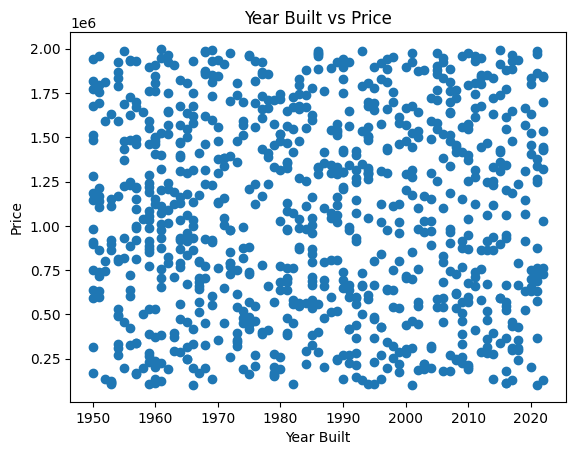

In [ ]:
plt.scatter(data['year_built'], data['price_usd'])
plt.xlabel("Year Built")
plt.ylabel("Price")
plt.title("Year Built vs Price")
plt.show()

Deploy House Price Prediction using Gradio (Step-by-Step)

after traing the model we deployed it is as a web applicationusing gradio

In [ ]:
!pip install gradio


In [ ]:
def predict_price(area, bedrooms, location):
    prediction = model.predict([[area, bedrooms, location]])
    return f"Predicted House Price: ${int(prediction[0])}"



In [ ]:
import gradio as gr

interface = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Number(label="Area (sq.ft)"),
        gr.Number(label="Number of Bedrooms"),
        gr.Number(label="Location Rating (1-10)")
    ],
    outputs="text",
    title="House Price Prediction App",
    description="Enter house details to predict price."
)


so usere can enter datails and get oredited price instantly

In [ ]:
interface.launch()



It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://13df9f8ae541e2aaf0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
